<h1><center>Uke 2 – Newtonfraktaler</center></h1>

<h3><center>IMAG3011 – Matematikk for ingeniørfag 3A</h3>

<p><center><strong>Bjørn Ivar Thorsen Høie</strong></center></p>

<p><center>NTNU Gjøvik</center></p>

<p><center>September 2026</center></p>

<br>

**Problemstilling:** Hva kjennetegner gode og dårlige startverdier for Newtons metode, og hvordan kan vi undersøke dette numerisk?


## Oppgave 1

_**Merknad:** Jeg vil gjøre leseren oppmersom på at jeg fikk samme funksjons-ID og funksjon som eksempelnavnet "Ada". Dette ser ut til å skyldes at programmet ikke behandlet fornavnet mitt "Bjørn" riktig, dette tror jeg skyldes at fornavnet mitt inneholder bokstaven "ø". Jeg oppdaget dette først når jeg begynnte å skrive rapporten, og oppgavene er allerede løst._


In [193]:
import hashlib
import unicodedata

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def normalize_name(name):
    """Gjør små navnevariasjoner irrelevante for funksjonstildelingen."""
    name = unicodedata.normalize("NFKD", name.strip().casefold())
    name = "".join(char for char in name
                   if not unicodedata.combining(char))
    return " ".join(name.split())


def function_id(first_name, number_of_functions):
    """Gjør fornavnet om til en stabil indeks i funksjonspuljen."""
    normalized = normalize_name(first_name)
    text = f"IMAX3011-newton-2026:{normalized}"
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], byteorder="big") % number_of_functions


FUNCTIONS = [
    {"label": "A", "coefficients": [1, 0, 0, -1],
     "formula": "z³ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "B", "coefficients": [1, -2j, -1, 2j],
     "formula": "(z − 1)(z + 1)(z − 2i)",
     "plot_window": (-2.5, 2.5, -2, 3)},
    {"label": "C", "coefficients": [1, 0, -2, -4],
     "formula": "(z − 2)(z + 1 − i)(z + 1 + i)",
     "plot_window": (-3, 3, -3, 3)},
    {"label": "D", "coefficients": [1, 0, 0, 0, -1],
     "formula": "z⁴ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "E", "coefficients": [1, 0, -3.75, 0, -1],
     "formula": "(z − 2)(z + 2)(z − 0.5i)(z + 0.5i)",
     "plot_window": (-3, 3, -2.5, 2.5)},
    {"label": "F", "coefficients": [1, 0, 0, 1, 1],
     "formula": "z⁴ + z + 1", "plot_window": (-2.5, 2.5, -2.5, 2.5)},
    {"label": "G", "coefficients": [1, 0, 0, 0, 0, -1],
     "formula": "z⁵ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "H", "coefficients": [1, -1.5, -0.5, -0.5, -1.5, 1],
     "formula": "(z − 2)(z + 1)(z − 0.5)(z − i)(z + i)",
     "plot_window": (-2.5, 2.5, -2.5, 2.5)},
    {"label": "I", "coefficients": [1, 0, 0, 0, -1, 1],
     "formula": "z⁵ − z + 1", "plot_window": (-2.5, 2.5, -2.5, 2.5)},
]


def prepare_function(entry):
    """Lag f, f', nullpunkter og kritiske punkter fra én tabellrad.

    Denne funksjonen gjør oppsettet for oss. I forsøkene nedenfor arbeider vi
    med f og df, og trenger vanligvis ikke å endre selve funksjonen her.
    """
    coefficients = np.asarray(entry["coefficients"], dtype=complex)
    derivative_coefficients = np.polyder(coefficients)
    roots = np.roots(coefficients)
    critical_points = np.roots(derivative_coefficients)

    def f(z):
        return np.polyval(coefficients, z)

    def df(z):
        return np.polyval(derivative_coefficients, z)

    return f, df, roots, critical_points


# Bytt teksten med ditt eget fornavn.
first_name = "Bjørn"

my_id = function_id(first_name, len(FUNCTIONS))
my_function = FUNCTIONS[my_id]
f, df, roots, critical_points = prepare_function(my_function)

print("Funksjons-ID:", my_function["label"])
print("Funksjon:    ", my_function["formula"])
print("Koeffisienter:", my_function["coefficients"])
print("Nullpunkter:")
for root in roots:
    print(" ", root)
print("Kritiske punkter (f'(z)=0):")
for point in critical_points:
    print(" ", point)
print("Standardvindu:", my_function["plot_window"])

Funksjons-ID: F
Funksjon:     z⁴ + z + 1
Koeffisienter: [1, 0, 0, 1, 1]
Nullpunkter:
  (0.7271360844911952+0.9340992894605284j)
  (0.7271360844911965-0.9340992894605294j)
  (-0.7271360844911973+0.4300142883297158j)
  (-0.7271360844911966-0.43001428832971583j)
Kritiske punkter (f'(z)=0):
  (-0.6299605249474372-3.3306690738754696e-16j)
  (0.31498026247371813-0.5455618179858606j)
  (0.31498026247371824+0.5455618179858607j)
Standardvindu: (-2.5, 2.5, -2.5, 2.5)


Funksjons ID-en, funksjonen, nullpunkter og standardvindu som er brukt gjennom prosjektet er:

**Funksjons-ID:**
$$
F
$$

**Funksjon:**

$$
f(z)=z^4+z+1
$$

**Nullpunkter:**

$$
r_1 = 0.7271360844911963 + 0.9340992894605291i
$$

$$
r_2 = 0.7271360844911976 - 0.9340992894605301i
$$

$$
r_3 = -0.727136084491198 + 0.43001428832971644i
$$

$$
r_4 = -0.7271360844911973 - 0.4300142883297161i
$$

**Standardvindu:**

$$
(-2.5,\;2.5,\;-2.5,\;2.5)
$$

## Oppgave 2

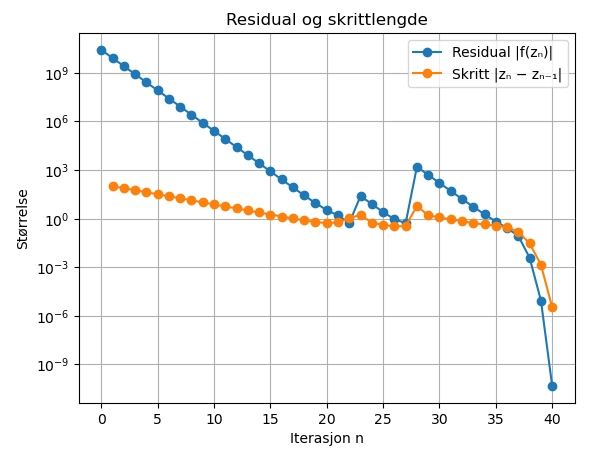

In [194]:
def is_finite_complex(z):
    """Sjekk at både real- og imaginærdelen kan brukes videre."""
    return np.isfinite(np.real(z)) and np.isfinite(np.imag(z))


def nearest_root(z, roots):
    """Returner nummeret til nullpunktet som ligger nærmest z."""
    return int(np.argmin(np.abs(roots - z)))


def newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50,
                 derivative_tol=1e-14):
    """Følg én startverdi slik at vi kan se hva Newton faktisk gjør.

    I forsøkene endrer du først og fremst z0, tol og maxiter. Resultatet er en
    ordbok med stoppårsak, funnet nullpunkt og hele iterasjonshistorikken.
    derivative_tol beskytter oss mot å dele på et tall som er svært nær null.
    """
    z = complex(z0)
    history = [{"n": 0, "z": z,
                "residual": float(abs(f(z))), "step": np.nan}]

    if history[-1]["residual"] < tol:
        return {"z": z, "converged": True, "root": nearest_root(z, roots),
                "reason": "liten residual", "iterations": 0,
                "history": history}

    for n in range(1, maxiter + 1):
        derivative = df(z)
        if not is_finite_complex(derivative) or abs(derivative) <= derivative_tol:
            return {"z": z, "converged": False, "root": None,
                    "reason": "for liten derivert", "iterations": n-1,
                    "history": history}

        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            z_new = z - f(z)/derivative

        if not is_finite_complex(z_new):
            return {"z": z_new, "converged": False, "root": None,
                    "reason": "ikke-endelig verdi", "iterations": n,
                    "history": history}

        step = float(abs(z_new-z))
        residual = float(abs(f(z_new)))
        history.append({"n": n, "z": z_new,
                        "residual": residual, "step": step})
        z = z_new

        if residual < tol:
            return {"z": z, "converged": True,
                    "root": nearest_root(z, roots),
                    "reason": "liten residual", "iterations": n,
                    "history": history}

    return {"z": z, "converged": False, "root": None,
            "reason": "maksimalt antall iterasjoner",
            "iterations": maxiter, "history": history}


def print_trace(result):
    """Skriv historikken fra newton_trace som en lesbar tabell."""
    print(" n                 z_n             |f(z_n)|       skrittlengde")
    for row in result["history"]:
        step = "     -" if np.isnan(row["step"]) else f"{row['step']:.3e}"
        print(f"{row['n']:2d}  {row['z']:>22.14g}   "
              f"{row['residual']:.3e}      {step}")
    print("\nStoppårsak:", result["reason"])
    print("Iterasjoner:", result["iterations"])
    if result["converged"]:
        print("Nærmeste nullpunkt:", roots[result["root"]])


def plot_trace(result):
    """Sammenlign residual og skrittlengde gjennom én iterasjon."""
    rows = result["history"]
    n = np.array([row["n"] for row in rows])
    residuals = np.array([row["residual"] for row in rows])
    steps = np.array([row["step"] for row in rows])

    plt.close("all")
    fig, ax = plt.subplots()
    ax.semilogy(n, residuals, "o-", label="Residual |f(zₙ)|")
    if len(steps) > 1:
        ax.semilogy(n[1:], steps[1:], "o-", label="Skritt |zₙ − zₙ₋₁|")
    ax.set_xlabel("Iterasjon n")
    ax.set_ylabel("Størrelse")
    ax.set_title("Residual og skrittlengde")
    ax.grid(True)
    ax.legend()
    plt.show()

In [195]:
starting_values = [1.5, -1+1j, 0.1, 1j]

for z0 in starting_values:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50)
    print("\nStartverdi:", z0)
    print("  konvergert:", result["converged"])
    print("  iterasjoner:", result["iterations"])
    print("  stoppårsak:", result["reason"])
    print("  siste residual:", result["history"][-1]["residual"])
    if result["converged"]:
        print("  nullpunkt:", roots[result["root"]])


Startverdi: 1.5
  konvergert: False
  iterasjoner: 50
  stoppårsak: maksimalt antall iterasjoner
  siste residual: 10.211344914375204

Startverdi: (-1+1j)
  konvergert: True
  iterasjoner: 6
  stoppårsak: liten residual
  siste residual: 3.935047005376569e-14
  nullpunkt: (-0.7271360844911973+0.4300142883297158j)

Startverdi: 0.1
  konvergert: False
  iterasjoner: 50
  stoppårsak: maksimalt antall iterasjoner
  siste residual: 10.091583786123321

Startverdi: 1j
  konvergert: True
  iterasjoner: 7
  stoppårsak: liten residual
  siste residual: 1.7099518709424534e-12
  nullpunkt: (-0.7271360844911966-0.43001428832971583j)


 n                 z_n             |f(z_n)|       skrittlengde
 0                   -1+1j   4.123e+00           -
 1  -0.80689655172414+0.71724137931034j   1.197e+00      3.424e-01
 2  -0.72209772828345+0.52368386473205j   2.770e-01      2.113e-01
 3  -0.71923022303569+0.43944773059165j   3.263e-02      8.428e-02
 4  -0.72691779129819+0.42990798124805j   6.406e-04      1.225e-02
 5  -0.72713618014755+0.430014286762j   2.525e-07      2.429e-04
 6  -0.72713608449121+0.4300142883297j   3.935e-14      9.567e-08

Stoppårsak: liten residual
Iterasjoner: 6
Nærmeste nullpunkt: (-0.7271360844911973+0.4300142883297158j)


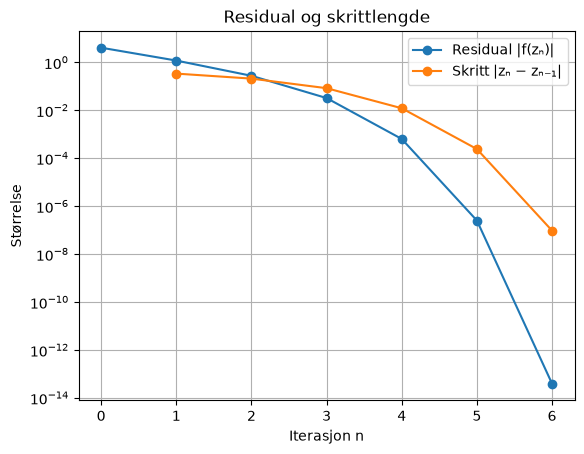

 n                 z_n             |f(z_n)|       skrittlengde
 0                  400+0j   2.560e+10           -
 1      299.99999882422+0j   8.100e+09      1.000e+02
 2      224.99999702557+0j   2.563e+09      7.500e+01
 3      168.74999404353+0j   8.109e+08      5.625e+01
 4      126.56248889626+0j   2.566e+08      4.219e+01
 5      94.921854843343+0j   8.118e+07      3.164e+01
 6       71.19137003036+0j   2.569e+07      2.373e+01
 7      53.393489834615+0j   8.127e+06      1.780e+01
 8      40.045049964169+0j   2.572e+06      1.335e+01
 9      30.033666656535+0j   8.137e+05      1.001e+01
10      22.525032899721+0j   2.575e+05      7.509e+00
11      16.893383260957+0j   8.146e+04      5.632e+00
12      12.669328623555+0j   2.578e+04      4.224e+00
13      9.5007055525522+0j   8.158e+03      3.169e+00
14      7.1231610782624+0j   2.583e+03      2.378e+00
15      5.3379867834952+0j   8.183e+02      1.785e+00
16      3.9952796306246+0j   2.598e+02      1.343e+00
17      2.980854328499

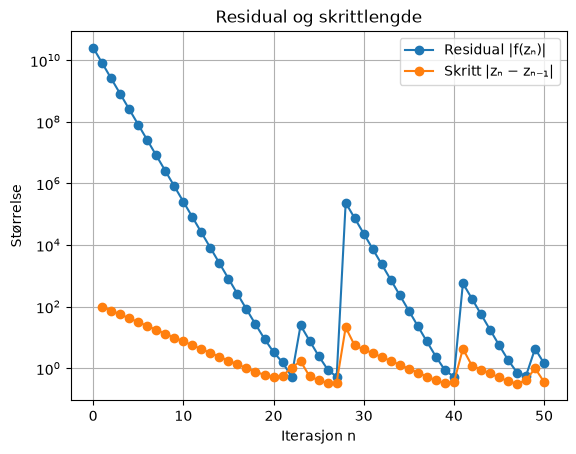

 n                 z_n             |f(z_n)|       skrittlengde
 0                    1+0j   3.000e+00           -
 1                  0.4+0j   1.426e+00      6.000e-01
 2    -0.73503184713376+0j   5.569e-01      1.135e+00
 3      0.2112588977858+0j   1.213e+00      9.463e-01
 4    -0.95789803502583+0j   8.840e-01      1.169e+00
 5    -0.60649801423211+0j   5.288e-01      3.514e-01
 6     -5.5200001527897+0j   9.239e+02      4.914e+00
 7     -4.1446742188967+0j   2.920e+02      1.375e+00
 8     -3.1159353629504+0j   9.215e+01      1.029e+00
 9     -2.3480917517667+0j   2.905e+01      7.678e-01
10     -1.7760548662042+0j   9.174e+00      5.720e-01
11     -1.3475503200523+0j   2.950e+00      4.285e-01
12     -1.0118760664559+0j   1.036e+00      3.357e-01
13    -0.68222871167531+0j   5.344e-01      3.296e-01
14      1.2960468714572+0j   5.118e+00      1.978e+00
15     0.76890164480871+0j   2.118e+00      5.271e-01
16     0.01723960380801+0j   1.017e+00      7.517e-01
17    -0.9999792407222

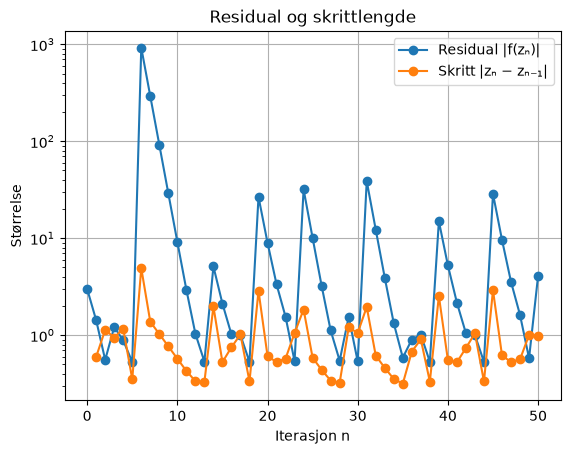

In [196]:
# Bytt startverdien med en verdi du vil undersøke nærmere.
z0 = -1 + 1j
z1 = 400+0.j
z2 = 1

result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50)
print_trace(result)
plot_trace(result)

result = newton_trace(f, df, roots, z1, tol=1e-8, maxiter=50)
print_trace(result)
plot_trace(result)

result = newton_trace(f, df, roots, z2, tol=1e-8, maxiter=50)
print_trace(result)
plot_trace(result)

### 1. Konvergerer alle startverdiene mot samme nullpunkt?

Nei funksjon z0 og z2 konvergerer mot samme nullpunkt
$$
-0.727136084491198+0.43001428832971644j.
$$
Vi kan se i iterasjonsforløpet til funksjon z2 at rundt steg 35 til 40 sp begynner den å ligne på iteratene til funksjon z0. Dette viser at iterasjonsforløpet etter hvert havner i samme områdre og konvergerer mot det samme nullpunktet.

Funksjonen z1 ser ut til å ikke konverger mot noen av nullpunktene. Residulaenen varier veldig og svinger opp og ned, og bergeningen stopper, fordi `maxiter` blir nådd.

<br>

### 2. Avtar residualen i hvert eneste steg
Nei residualen er ikke garantert til å avta i hvert eneste steg.

I graf A så avtar residualen i hvert eneste steg og går mot null

I i graf B så varier residualen mye og går opp og ned.

I graf C så avtar residualen og går mot null, men residualen øker enekelte steder underveis. For eksempel rundt iterasjon 20 og 30 så øker residualen to ganger, men etter det så går den tilbake til å gå mot null.

<br>

### 3. Avtar residual og skrittlengde i samme takt?

Residualen og skrittlengden avtar i samme takt. Ser vi ut ifra grafen så kan vi lese at når residualen avtar så avtar også skrittlengden, samme når residualen øker så øker skrittlengden.

<br>

### 4. Hvorfor trenger programmet både residualtoleranse og `maxiter`?

Programmet trenger residualtoleranse for å avgjør når en løsning er god nok. Når løsningen når grensen vi har satt oss så regnes iterasjonen som konvergert, og programmet kan stoppe.

`maxiter` fungerer som en grense for antall iterasjoner som skal gjennomføres. Uten `maxiter` kunne programmet fortsatt å regne nye iterasjoner lenge dersom residualen alldri blir god nok. Dette ser vi for eksempel i grafen til funksjonen z1 hvor den ikke konvergerer mot et nullpunkt og når `maxiter` grensen på 50 iterasjoner.

### 5. Hva skjer dersom et iterat kommer nært et punkt det $f'(z)=0$?
Hvis iteratet kommer nærme null, vil programmet måtte dele på et veldig lite tall. Dermed kan dette føre til at steget blir veldig stort, f.eks:

$$
\frac{f(z)}{f'(z)}=\frac{0.1}{0.00001}=10\,000
$$

Dette kan forklare hvorfor i noen tilfeller hvor skrittlengden plutselig øker.

## Oppgave 3

In [197]:
def newton_grid(f, df, roots, bounds, nx=400, ny=400,
                tol=1e-8, maxiter=50, derivative_tol=1e-14):
    """Kjør det samme Newton-forsøket for alle pikslene i et rektangel.

    bounds velger delen av det komplekse planet vi ser. nx og ny bestemmer
    bildeoppløsningen, ikke nøyaktigheten til én Newton-iterasjon. Returverdien
    inneholder både funnet nullpunkt, iterasjonstall og sluttresidual.
    """
    xmin, xmax, ymin, ymax = bounds
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    z = x[None, :] + 1j*y[:, None]

    basin = np.full(z.shape, -1, dtype=int)
    iterations = np.zeros(z.shape, dtype=int)
    # active forteller hvilke piksler som fortsatt trenger et nytt Newton-skritt.
    active = np.ones(z.shape, dtype=bool)

    for n in range(1, maxiter + 1):
        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            derivative = df(z)
            safe = (active & np.isfinite(z.real) & np.isfinite(z.imag)
                    & np.isfinite(derivative.real)
                    & np.isfinite(derivative.imag)
                    & (np.abs(derivative) > derivative_tol))

            # Skill ugyldige beregninger fra dem som bare trenger flere steg.
            invalid = active & ~safe
            basin[invalid] = -2
            iterations[invalid] = n-1
            active[invalid] = False

            z[safe] = z[safe] - f(z[safe])/derivative[safe]
            finite = np.isfinite(z.real) & np.isfinite(z.imag)
            invalid_after = active & ~finite
            basin[invalid_after] = -2
            iterations[invalid_after] = n
            active[invalid_after] = False

            residual = np.full(z.shape, np.inf)
            residual[active] = np.abs(f(z[active]))
            converged = active & (residual < tol)

        if np.any(converged):
            # Først nå bestemmer vi hvilket nullpunkt pikslene endte ved.
            converged_values = z[converged]
            distances = np.abs(converged_values[:, None] - roots[None, :])
            basin[converged] = np.argmin(distances, axis=1)
            iterations[converged] = n
            active[converged] = False

        if not np.any(active):
            break

    iterations[active] = maxiter
    final_residual = np.full(z.shape, np.inf)
    finite = np.isfinite(z.real) & np.isfinite(z.imag)
    with np.errstate(over="ignore", invalid="ignore"):
        final_residual[finite] = np.abs(f(z[finite]))

    return {"basin": basin, "iterations": iterations,
            "residual": final_residual, "z": z,
            "bounds": bounds, "tol": tol, "maxiter": maxiter,
            "roots": roots}


ROOT_COLORS = np.array([
    [0.90, 0.20, 0.20], [0.20, 0.65, 0.95], [0.25, 0.80, 0.35],
    [0.90, 0.65, 0.15], [0.65, 0.35, 0.90], [0.20, 0.80, 0.80],
])


def plot_basins(data, title="Newtons metode: tiltrekningsområder",
                critical_points=None, iteration_cap=20):
    """Vis resultat og arbeidsmengde i hvert sitt panel.

    Venstre panel svarer på hvilket nullpunkt som ble funnet. Høyre panel
    viser antall iterasjoner. iteration_cap bestemmer hvor fargeskalaen
    stopper; større verdier vises fortsatt, men får samme endefarge.
    """
    basin = data["basin"]
    iterations = data["iterations"]
    maxiter = data["maxiter"]
    roots = data["roots"]
    xmin, xmax, ymin, ymax = data["bounds"]

    # Basin-fargen skal bare kode nullpunkt, ikke iterasjonstall.
    basin_image = np.full(basin.shape + (3,), 0.25)
    basin_image[basin == -2] = 0.0
    legend_handles = []
    for k in range(len(roots)):
        mask = basin == k
        color = ROOT_COLORS[k % len(ROOT_COLORS)]
        basin_image[mask] = color
        legend_handles.append(Patch(facecolor=color, label=f"Mot r{k+1}"))

    plt.close("all")
    fig, (ax_basin, ax_iterations) = plt.subplots(
        1, 2, figsize=(13, 6), constrained_layout=True
    )

    ax_basin.imshow(basin_image, origin="lower",
                    extent=(xmin, xmax, ymin, ymax),
                    interpolation="nearest")
    ax_basin.scatter(roots.real, roots.imag, c="white", edgecolors="black",
                     s=70, marker="o")
    for k, root in enumerate(roots):
        ax_basin.annotate(f"r{k+1}", (root.real, root.imag),
                          xytext=(7, 7), textcoords="offset points",
                          color="black", weight="bold")
    if critical_points is not None:
        critical_handle = ax_basin.scatter(
            critical_points.real, critical_points.imag,
            c="black", edgecolors="white", s=70, marker="X",
            linewidths=1.5, label="Kritiske punkter"
        )
        legend_handles.append(critical_handle)

    ax_basin.set_title("Funnet nullpunkt")
    ax_basin.legend(handles=legend_handles, loc="best")

    converged = basin >= 0
    # Avkort skalaen slik at noen få trege piksler ikke vasker ut hele kartet.
    capped_iterations = np.ma.masked_where(
        ~converged, np.minimum(iterations, iteration_cap)
    )
    iteration_image = ax_iterations.imshow(
        capped_iterations, origin="lower", extent=(xmin, xmax, ymin, ymax),
        interpolation="nearest", cmap="viridis",
        vmin=1, vmax=iteration_cap
    )
    ax_iterations.scatter(roots.real, roots.imag, c="white",
                          edgecolors="black", s=45, marker="o")
    colorbar = fig.colorbar(iteration_image, ax=ax_iterations, shrink=0.82)
    colorbar.set_label(
        f"Antall iterasjoner ({iteration_cap} = {iteration_cap} eller flere)"
    )
    ax_iterations.set_title("Iterasjoner før residualkravet er oppfylt")

    for ax in (ax_basin, ax_iterations):
        ax.set_xlabel("Re(z₀)")
        ax.set_ylabel("Im(z₀)")
        ax.set_aspect("equal")

    fig.suptitle(title)
    plt.show()


def summarize_grid(data):
    """Trekk ut noen få tall som gjør ulike rutenett sammenlignbare."""
    basin = data["basin"]
    iterations = data["iterations"]
    residual = data["residual"]
    converged = basin >= 0
    total = basin.size

    summary = {
        "total": total,
        "converged": int(np.count_nonzero(converged)),
        "not_converged": int(np.count_nonzero(basin == -1)),
        "invalid": int(np.count_nonzero(basin == -2)),
        "fraction_converged": float(np.mean(converged)),
        "mean_iterations": (float(np.mean(iterations[converged]))
                            if np.any(converged) else np.nan),
        "max_accepted_residual": (float(np.max(residual[converged]))
                                  if np.any(converged) else np.nan),
    }
    return summary


def print_summary(summary):
    """Skriv sammendraget uten at vi må huske alle nøkkelnavnene."""
    print("Antall startverdier:     ", summary["total"])
    print("Konvergert:              ", summary["converged"])
    print("Nådde maxiter:           ", summary["not_converged"])
    print("Ugyldig beregning:       ", summary["invalid"])
    print("Andel konvergert:        ", f"{summary['fraction_converged']:.4f}")
    print("Gjennomsnitt iterasjoner:", f"{summary['mean_iterations']:.2f}")
    print("Største godkjente residual:",
          f"{summary['max_accepted_residual']:.3e}")

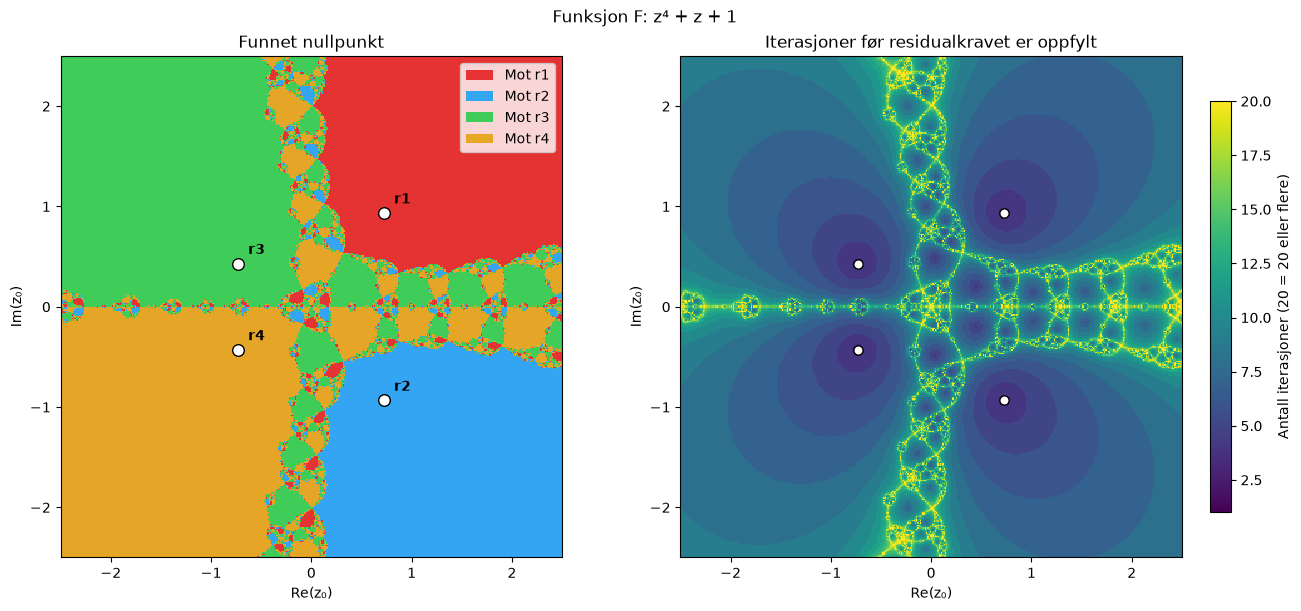

Antall startverdier:      160000
Konvergert:               160000
Nådde maxiter:            0
Ugyldig beregning:        0
Andel konvergert:         1.0000
Gjennomsnitt iterasjoner: 8.26
Største godkjente residual: 9.996e-09


In [198]:
bounds = my_function["plot_window"]

basin_data = newton_grid(
    f, df, roots,
    bounds=bounds,
    nx=400, ny=400,
    tol=1e-8,
    maxiter=50,
)

plot_basins(basin_data, f"Funksjon {my_function['label']}: {my_function['formula']}")
print_summary(summarize_grid(basin_data))

In [199]:
def first_start_in(data, mask):
    """Finn én startverdi i en kategori, hvis kategorien finnes."""
    indices = np.argwhere(mask)
    if len(indices) == 0:
        return None
    row, col = indices[len(indices)//2]
    xmin, xmax, ymin, ymax = data["bounds"]
    ny, nx = data["basin"].shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    return x[col] + 1j*y[row]


converged = basin_data["basin"] >= 0
categories = {
    "rask": converged & (basin_data["iterations"] <= 6),
    "langsom": converged & (basin_data["iterations"] > 15),
    "mislykket": basin_data["basin"] < 0,
}

for name, mask in categories.items():
    print(f"Forslag, {name}:", first_start_in(basin_data, mask))

Forslag, rask: (0.4323308270676689+0.018796992481203034j)
Forslag, langsom: (-2.5+0.006265664160400863j)
Forslag, mislykket: None


### 1. Hvilke områder konvergerer mot hvert nullpunkt?
- Rød område konverger mot r1
- Blått område konverger mot r2
- Grønt område konverger mot r3
- Orasnje område konverger mot r4

<br>

### 2. Hvor ligger startverdiene som krever flest iterasjoner?
Startverdiene som krever flest iterasjoner ligge i følsomme område hvor det er flere farger nær hverandre. Vi ser at de ligger i et kryss, langs en linke vertikalt y = 0 og horisontalt x = 0.

<br>

### 3. Hvordan skiller punkter nær en grense seg fra punkter langt inne i et tiltrekningsområde?
Det nærmer vi er tiltrekningsområpde det færre antall iterasjoner bruker newtons metode på å nå residualkravet. Punktene nær en grense bruker mer iterasjoner får å nå ett av nullpunktene.

<br>

### 4. Ser figuren symmetrisk ut? Sammenlign med plasseringen av nullpunktene.

r3 og r4 punktene ligger symmetrisk ovenfor hverandre, det samme gjelder for r1 og r2. Hadde vi brett grafen nedover så ville områdene i stor grad speilet hverandre, et motsatte farge. Vi ser at oransj og grønn speiler hverandre, og rødt og blått speiler hverandre. Denne symetriene funger ikek fra venstre mot høyre.

<br>

### 5. Kan et endelig rutenett bevise at alle startverdier i vinduet konvergerer?

Nei, alle de 160000 testede startverdiene konvergerte, men det betyr at det er flere punkter vi ikke har testet. Tester vi flere punkter vil ikke det nødvendigvis si at de kommer til å konvergere mot et nulllpunkt

## Oppgave 4

In [200]:
def compare_with_nearest(data):
    """Test nærmeste-nullpunkt-gjetningen på hele rutenettet."""
    basin = data["basin"]
    roots = data["roots"]
    xmin, xmax, ymin, ymax = data["bounds"]
    ny, nx = basin.shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    z0 = x[None, :] + 1j*y[:, None]

    nearest = np.argmin(np.abs(z0[..., None] - roots), axis=2)
    converged = basin >= 0
    different = converged & (basin != nearest)
    fraction = np.count_nonzero(different) / np.count_nonzero(converged)
    return {"nearest": nearest, "different": different,
            "fraction": fraction, "z0": z0}


nearest_test = compare_with_nearest(basin_data)
print("Andel konvergerte startverdier som ikke fant nærmeste nullpunkt:",
      f"{nearest_test['fraction']:.4f}")

indices = np.argwhere(nearest_test["different"])
print("Noen moteksempler:")
for row, col in indices[:5]:
    z0 = nearest_test["z0"][row, col]
    nearest_index = nearest_test["nearest"][row, col]
    found_index = basin_data["basin"][row, col]
    print(f"z₀={z0:.5g}: nærmest {roots[nearest_index]:.5g}, "
          f"men fant {roots[found_index]:.5g}")

Andel konvergerte startverdier som ikke fant nærmeste nullpunkt: 0.1763
Noen moteksempler:
z₀=-0.6203-2.5j: nærmest 0.72714-0.9341j, men fant -0.72714-0.43001j
z₀=-0.60777-2.5j: nærmest 0.72714-0.9341j, men fant -0.72714-0.43001j
z₀=-0.59524-2.5j: nærmest 0.72714-0.9341j, men fant -0.72714-0.43001j
z₀=-0.58271-2.5j: nærmest 0.72714-0.9341j, men fant -0.72714-0.43001j
z₀=-0.57018-2.5j: nærmest 0.72714-0.9341j, men fant -0.72714-0.43001j


 n                 z_n             |f(z_n)|       skrittlengde
 0  -0.57017543859649-2.5j   4.547e+01           -
 1  -0.41159994661398-1.8510730174815j   1.475e+01      6.680e-01
 2  -0.28582803623823-1.337633377436j   4.987e+00      5.286e-01
 3  -0.19099829487144-0.88821135456786j   1.883e+00      4.593e-01
 4  -0.2003280486409-0.37699981897372j   8.866e-01      5.113e-01
 5  -0.79334816407237-0.05073326611659j   5.952e-01      6.768e-01
 6  -0.24781514324073-0.21372929461532j   7.705e-01      5.694e-01
 7  -0.95037132405403-0.095423147430869j   8.476e-01      7.124e-01
 8  -0.6210410976334-0.14287636228891j   4.811e-01      3.327e-01
 9  -0.84272245731921-0.81695163055584j   1.872e+00      7.096e-01
10  -0.72711501967154-0.58318321417254j   4.879e-01      2.608e-01
11  -0.71088976189368-0.45541439103693j   8.092e-02      1.288e-01
12  -0.72573373294403-0.42976866663815j   3.751e-03      2.963e-02
13  -0.7271388420754-0.43001248948021j   8.690e-06      1.426e-03
14  -0.7271360844826

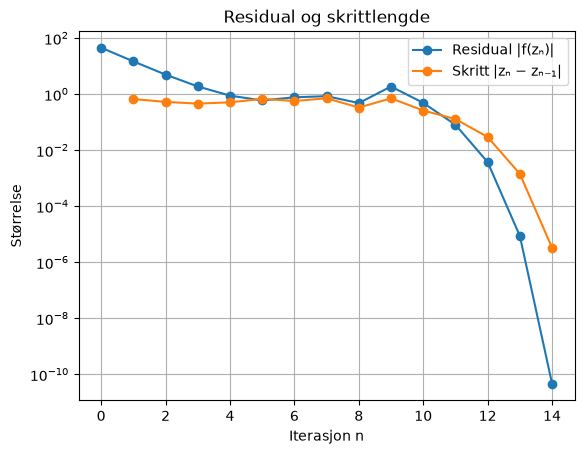

In [201]:
moteksempel = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50)
print_trace(moteksempel)
plot_trace(moteksempel)

### 1. Hvor stor andel av de konvergerte startverdiene fant ikke nærmeste nullpunkt?
17.63 % av startverdiene som konvergerte fant ikke det nærmeste nullpunktet og endte opp med et annet nullpunkt

<br>

### 2. Hva skjer med avstanden til de ulike nullpunktene gjennom ditt valgte forløp?
Avstanden mellom de ulike nullpunktene varierer. Ser vi fra punkt 5 til 7 ser vi den hopper fra

$$
−0.793348−0.050733i \rightarrow−0.247815−0.213729i \rightarrow
 −0.950371−0.095423i
$$
Newton iterasjonen i starten beveger seg mellom områdene og går ikke mot et spesielt nullpunkt. Rundt iterasjon 10 så ser vi at den beveger seg mot ett nullpunkt til den slutter på iterasjon 14 og er nærmest nullpunktet:

$$
-0.7271360844911973-0.4300142883297161j
$$

<br>

### 3. Hvor i tiltrekningsplottet ligger de fleste moteksemplene?

De fleste moteksemplene ligger nær grensene mellom tiltrekningsområdene, hvor små endringer i startverdien kan føre til at newtons metode går mot et annet nullpunkt.

<br>

### 4. Hva kan du nå si om påstanden «Newton finner nærmeste nullpunkt»?

Ligger startverdien nærme et grense område og et stykke unda nullpunktet, så går den ikke nødvendivis mot nærmeste nulllpunktet, men et annet nullpunkt som ligger lengre vekke. Så påstanden "Newton finner nærmeste nullpunkt" stemmer i de fleste tilfellene, men ikke alle.

## Oppgave 5

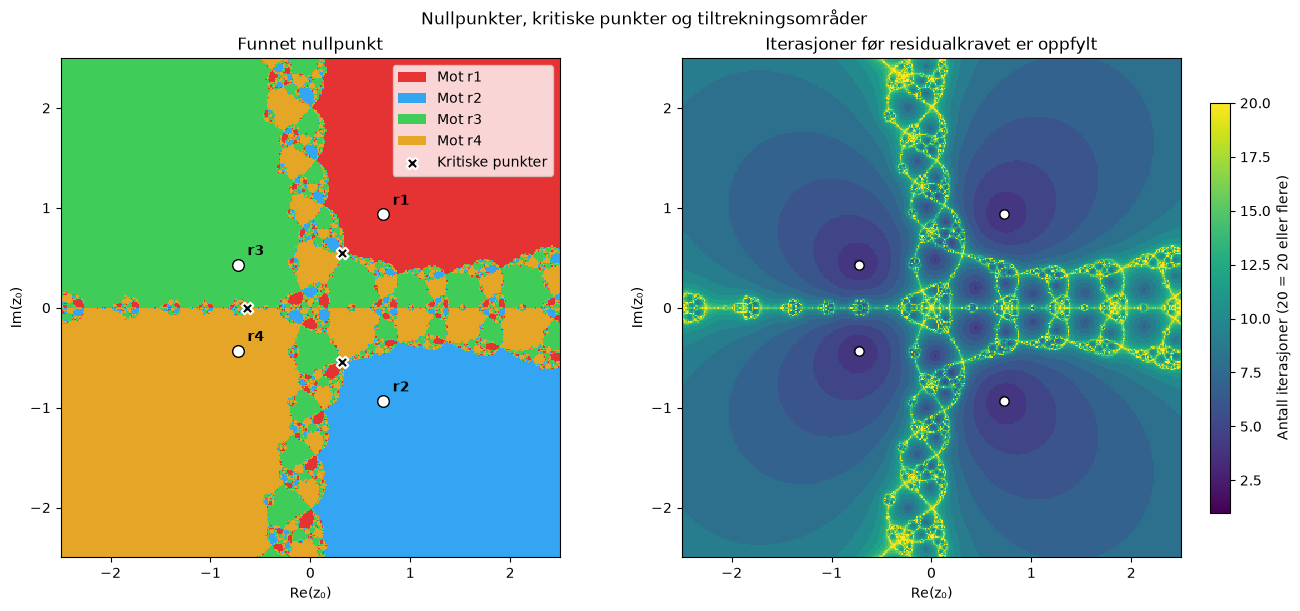

Kritiske punkter:
  (-0.6299605249474372-3.3306690738754696e-16j)   |f(z)| = 0.5275296062894226
  (0.31498026247371813-0.5455618179858606j)   |f(z)| = 1.3021899502928156
  (0.31498026247371824+0.5455618179858607j)   |f(z)| = 1.3021899502928156


In [202]:
plot_basins(basin_data,
            "Nullpunkter, kritiske punkter og tiltrekningsområder",
            critical_points=critical_points)

print("Kritiske punkter:")
for point in critical_points:
    print(" ", point, "  |f(z)| =", abs(f(point)))

In [203]:
c = critical_points[0]  # Velg eventuelt et annet kritisk punkt.
critical_starts = [c, c + 1e-3, c + 1e-2j]

for z0 in critical_starts:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=100)
    steps = [row["step"] for row in result["history"]
             if np.isfinite(row["step"])]
    largest_step = max(steps) if steps else np.nan
    found = roots[result["root"]] if result["converged"] else "ikke funnet"
    print(f"z₀={z0:.8g}: stopp={result['reason']}, "
          f"største skritt={largest_step:.3e}, "
          f"iterasjoner={result['iterations']}, nullpunkt={found}")

z₀=-0.62996052-3.3306691e-16j: stopp=for liten derivert, største skritt=nan, iterasjoner=0, nullpunkt=ikke funnet
z₀=-0.62896052-3.3306691e-16j: stopp=liten residual, største skritt=1.110e+02, iterasjoner=71, nullpunkt=(-0.7271360844911966-0.43001428832971583j)
z₀=-0.62996052+0.01j: stopp=liten residual, største skritt=1.107e+01, iterasjoner=18, nullpunkt=(-0.7271360844911966-0.43001428832971583j)


### 1. Hva skjer når startverdien er nøyaktig et kritisk punkt?

Når startverdien er et kritsk punkt vil det si at $f´(z_0)=0$. Derfor vil programmet prøve å dele på null, noe som ikke er mattematisk tillat. Programmet skriver derfor ut:
```
- stopp = skriver for liten derivert
- største skritt = nan
- iterasjoner = 0
- nullpunkt = ikke funnet
```

<br>

### 2. Hvordan oppfører de to nærliggende startverdiene seg?

Det første nærliggende startpunktet bruker 74 iterasjoner for å nå nullpunktet, og har sitt største skritt på 111.

Det andre startpunktet bruker bare 18 iterasjoner og har sitt største skritt på 11.07.

Dette viser at små endringer nær et kritisk punkt kan gi forskjellige iterasjonsforeløp.

<br>

### 3. Ligger områder med mange iterasjoner nær noen av de kritiske punktene?

Områder med mange iterasjoner ligge nær de kritiske punktene. Dette stemmer med at $f´(<)$ er liten der, noe som kan føre til at vi får store Newton skritt.

<br>

### 4. Er liten $|f'(z_0)|$ alene nok til å forutsi hele iterasjonsforløpet?

Vi kan ikke vite hvordan resten av Newton iterasjonen kommer til å gå. $|f'(z_0)|$ forteller oss hvordan første iterasjonen kommer til å gå, men gir ingen indikasjon hvor resten av iterasjonene vil bli.

## Oppgave 6

In [204]:
def suggest_boundary_point(data):
    """Finn et sentralt sted der to nabopiksler har forskjellig farge."""
    basin = data["basin"]
    left = basin[:, :-1]
    right = basin[:, 1:]
    candidates = np.argwhere((left >= 0) & (right >= 0) & (left != right))
    if len(candidates) == 0:
        raise ValueError("Fant ingen grense mellom to tiltrekningsområder")

    ny, nx = basin.shape
    margin_y = max(1, ny//20)
    margin_x = max(1, nx//20)
    interior = candidates[(candidates[:, 0] >= margin_y)
                          & (candidates[:, 0] < ny-margin_y)
                          & (candidates[:, 1] >= margin_x)
                          & (candidates[:, 1] < nx-margin_x)]
    if len(interior) > 0:
        candidates = interior

    center = np.array([ny/2, nx/2])
    row, col = candidates[np.argmin(np.sum((candidates-center)**2, axis=1))]
    xmin, xmax, ymin, ymax = data["bounds"]
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    return (x[col] + x[col+1])/2 + 1j*y[row]


boundary_point = suggest_boundary_point(basin_data)
delta = 1e-3
nearby_starts = [boundary_point,
                 boundary_point + delta,
                 boundary_point + 1j*delta]

print("Foreslått grensepunkt:", boundary_point)
for z0 in nearby_starts:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=100)
    found = roots[result["root"]] if result["converged"] else "ikke funnet"
    print(f"z₀={z0:.8g}: {result['iterations']} iterasjoner, "
          f"nullpunkt={found}, stopp={result['reason']}")
    # Fjern kommentarene for å se iterasjonsforeløpet for startverdienee
    #print("Iterasjonsforeløp")
    #print_trace(result)

Foreslått grensepunkt: (0.012531328320801949+0.006265664160400863j)
z₀=0.012531328+0.0062656642j: 27 iterasjoner, nullpunkt=(-0.7271360844911973+0.4300142883297158j), stopp=liten residual
z₀=0.013531328+0.0062656642j: 26 iterasjoner, nullpunkt=(-0.7271360844911966-0.43001428832971583j), stopp=liten residual
z₀=0.012531328+0.0072656642j: 24 iterasjoner, nullpunkt=(-0.7271360844911973+0.4300142883297158j), stopp=liten residual


### 1. Hvor stor var avstanden mellom de to valgte startverdiene?

Avstanden mellom de to valgte nullpunktene er 0.001

$|z_1-z_2|=\sqrt{(0.013531328-0.012531328)^2+(0.0062656642-0.0062656642)^2}$

$|z_1-z_2|=\sqrt{0.001^2}=0.001$

<br>

### 2. Når begynte iterasjonsforløpene å bli tydelig forskjellige?

Rundt iterasjon nr 15 ser vi at det blir en mer tydelig forskjell mellom startverdiene. I punkt 16 ser vi at skrittlengden til det andre punktet (5.625e+00) er større enn det første punktet (2.413e+00).

<br>

### 3. Fant de ulike nullpunkter, eller var forskjellen bare antall iterasjoner?

Begge punktene fant samme nullpunkt, eneste forskjellen er at det første startverdien brukte 1 ekstra iterasjon for å nå nullpunktet, mens den andre startverdien brukte en mindre. Startverdi nr. 1 brukte 27 iterasjoner mens startverdi nr. 2 brukte 26

<br>

### 4. Er samme følsomhet synlig langt inne i et ensfarget område?

Langt inne i et ensfarget område vil små endringer i startverdien føre til samme nullpunkt, så metoden er mindre følsom der.

## Oppgave 7

#### Orginal kode

In [205]:
print("      tol  maxiter  konvergert  nådde grensen  gj.snitt steg")
for tolerance, maximum in [(1e-4, 50), (1e-8, 50),
                           (1e-12, 50), (1e-8, 15), (1e-8, 100)]:
    data = newton_grid(f, df, roots, bounds, nx=250, ny=250,
                       tol=tolerance, maxiter=maximum)
    summary = summarize_grid(data)
    print(f"{tolerance:9.0e}  {maximum:7d}  {summary['converged']:10d}  "
          f"{summary['not_converged']:13d}  "
          f"{summary['mean_iterations']:13.2f}")

      tol  maxiter  konvergert  nådde grensen  gj.snitt steg
    1e-04       50       62500              0           7.32
    1e-08       50       62500              0           8.26
    1e-12       50       62500              0           8.82
    1e-08       15       60428           2072           7.89
    1e-08      100       62500              0           8.26


### Endret kode

In [206]:
print("      tol  maxiter  konvergert  nådde grensen  gj.snitt steg")
for tolerance, maximum in [(1e-4, 50), (1e-8, 50),
                           (1e-12, 50), (1e-8, 50), (1e-8, 100)]:
    data = newton_grid(f, df, roots, bounds, nx=250, ny=250,
                       tol=tolerance, maxiter=maximum)
    summary = summarize_grid(data)
    print(f"{tolerance:9.0e}  {maximum:7d}  {summary['converged']:10d}  "
          f"{summary['not_converged']:13d}  "
          f"{summary['mean_iterations']:13.2f}")

      tol  maxiter  konvergert  nådde grensen  gj.snitt steg
    1e-04       50       62500              0           7.32
    1e-08       50       62500              0           8.26
    1e-12       50       62500              0           8.82
    1e-08       50       62500              0           8.26
    1e-08      100       62500              0           8.26


### 1. Forklar med konkrete tall hvordan en strengere toleranse og en større maxiter påvirker klassifiseringen. Betyr «nådde maxiter» at den matematiske følgen divergerer?

Med en strengere toleranse vil vi komme nærmere nullpunktet, men da vil det ta lengre tid før punktet blir klassifisert som konvergert. Dette kan resultere i at noen startverdier når `maxiter` før de rekker å oppfylle toleransekravet.

Det at en startverdi har nådd `maxiter` betyr ikke nødvendigvis at den matematiske følgen divergerer, men bare at den ikke kom til et punkt som oppfylte toleransen innenfor antall steg vi hadde satt. Altså kan det være at den bare ikke fikk nok steg.

For eksempel ser vi at med `tol = 1e-4` og `maxiter = 50` bruker metoden i gjennomsnitt `7.32` steg. Gjør vi toleransen strengere til `tol = 1e-8`, øker gjennomsnittet til `8.26` steg, siden metoden trenger flere steg for å nå toleransen vi har satt.

Med `maxiter = 15` klarer metoden å konvergere for `60428` av punktene. Øker vi `maxiter` til `50`, konvergerer alle `62500` punktene. Gjennomsnittlig antall steg øker da fra `7.89` til `8.26`, siden noen av punktene får mulighet til å ta flere steg før de stopper.

### 2. Betyr $|f(z_n)| < 10^{-12}$ nødvendigvis at $|z_n-r| < 10^{-12}$?

Nei det er fordi residualen sier hvor nær funksjonsverdien er 0, mens den andre forteller hvor stor avstanden er mellom itetaratet og det faktiske til nullpunktet.

## Oppgave 8

### Delproblem 1

In [207]:
def boundary_mask(data):
    """Marker piksler ved en overgang mellom to konvergensområder.

    Vi teller bare overganger mellom punkter som faktisk konvergerte. Punkter
    som nådde maxiter eller ga en ugyldig beregning får ikke lage en kunstig
    basin-grense.
    """
    basin = data["basin"]
    boundary = np.zeros(basin.shape, dtype=bool)

    # Sammenlign naboer mot venstre og høyre.
    valid_horizontal = (basin[:, :-1] >= 0) & (basin[:, 1:] >= 0)
    changes_horizontal = valid_horizontal & (basin[:, :-1] != basin[:, 1:])
    boundary[:, :-1] |= changes_horizontal
    boundary[:, 1:] |= changes_horizontal

    # Gjør samme sammenligning opp og ned.
    valid_vertical = (basin[:-1, :] >= 0) & (basin[1:, :] >= 0)
    changes_vertical = valid_vertical & (basin[:-1, :] != basin[1:, :])
    boundary[:-1, :] |= changes_vertical
    boundary[1:, :] |= changes_vertical
    return boundary


def boundary_summary(data):
    """Sammenlign Newton-arbeidet på grensen og inne i basinene."""
    boundary = boundary_mask(data)
    converged = data["basin"] >= 0
    interior = converged & ~boundary
    iterations = data["iterations"]

    return {
        "boundary_fraction": np.count_nonzero(boundary)
                             / np.count_nonzero(converged),
        "mean_boundary_iterations": np.mean(iterations[boundary]),
        "mean_interior_iterations": np.mean(iterations[interior]),
        "max_boundary_iterations": np.max(iterations[boundary]),
        "visible_basins": len(np.unique(data["basin"][converged])),
    }


def print_boundary_summary(data):
    """Skriv de samme målene for hvert zoomnivå."""
    summary = boundary_summary(data)
    xmin, xmax, ymin, ymax = data["bounds"]
    pixel_width = (xmax-xmin)/(data["basin"].shape[1]-1)

    print("Bredde på vinduet:       ", f"{xmax-xmin:.4e}")
    print("Bredde per piksel:       ", f"{pixel_width:.4e}")
    print("Synlige basin:           ", summary["visible_basins"])
    print("Andel grensepiksler:     ", f"{summary['boundary_fraction']:.4f}")
    print("Gj.snitt steg, grense:   ",
          f"{summary['mean_boundary_iterations']:.2f}")
    print("Gj.snitt steg, indre:    ",
          f"{summary['mean_interior_iterations']:.2f}")
    print("Største steg, grense:    ", summary["max_boundary_iterations"])

In [208]:
print_boundary_summary(basin_data)

Bredde på vinduet:        5.0000e+00
Bredde per piksel:        1.2531e-02
Synlige basin:            4
Andel grensepiksler:      0.0870
Gj.snitt steg, grense:    15.08
Gj.snitt steg, indre:     7.61
Største steg, grense:     43


### Hypotese
Jeg forventer at grensen etter hvert vil bli glattere dersom jeg zoomer langt nok inn.

Jeg forventer også at indre piksler vil kreve færre iterasjoner enn grensepiksler, siden startverdier nær grensene ofte er mer følsomme og bruker lengre tid på å konvergere.

### Kode brukt for delproblem 2 og 3

#### Orginal Kode

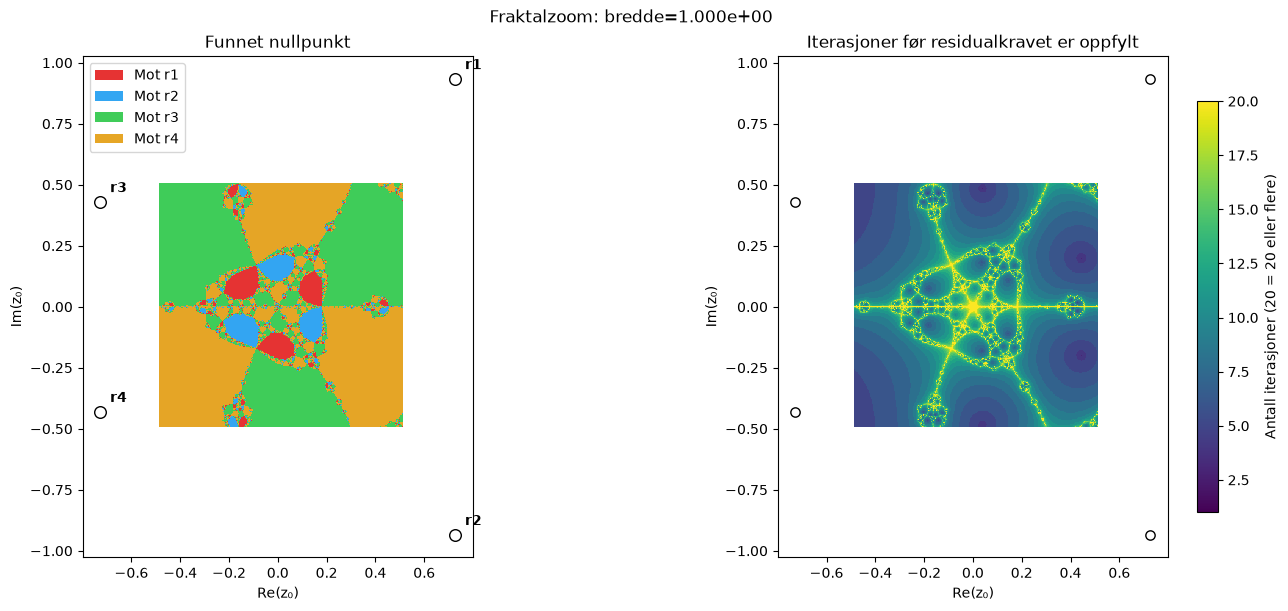

Bredde på vinduet:        1.0000e+00
Bredde per piksel:        2.5063e-03
Synlige basin:            4
Andel grensepiksler:      0.1108
Gj.snitt steg, grense:    17.80
Gj.snitt steg, indre:     8.34
Største steg, grense:     96


In [209]:
def square_bounds(center, width):
    """Lag et kvadratisk vindu rundt startverdien vi vil følge."""
    half = width/2
    return (center.real-half, center.real+half,
            center.imag-half, center.imag+half)


def run_zoom(center, width, resolution=400, tol=1e-8, maxiter=100):
    """Beregn og vis ett nytt nivå i fraktalzoomen.

    Behold resolution, tol og maxiter når du sammenligner nivåene. Endre
    center og width for å følge grensen videre.
    """
    zoom_bounds = square_bounds(center, width)
    data = newton_grid(
        f, df, roots, zoom_bounds,
        nx=resolution, ny=resolution, tol=tol, maxiter=maxiter
    )
    plot_basins(data, f"Fraktalzoom: bredde={width:.3e}")
    print_boundary_summary(data)
    return data


# Dette er nivå 1. Endre sentrum hvis grensen forsvinner ut av bildet.
zoom_center = boundary_point
zoom_width = min(bounds[1]-bounds[0], bounds[3]-bounds[2]) / 5
zoom_data = run_zoom(zoom_center, zoom_width)

#### Endret kode
_Brukte KI til å  lage en plot_basins2 basert på plot_basins får å fylle opp grafen slik det blir lettere å lese grafen._

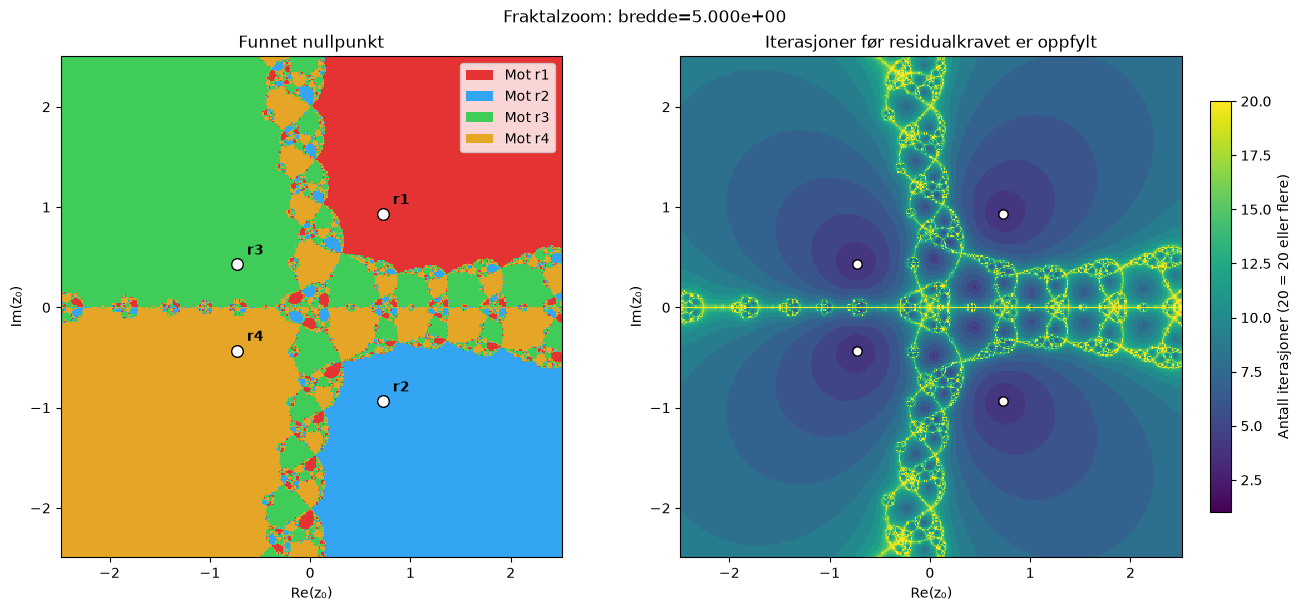

Bredde på vinduet:        5.0000e+00
Bredde per piksel:        1.2531e-02
Synlige basin:            4
Andel grensepiksler:      0.0871
Gj.snitt steg, grense:    16.68
Gj.snitt steg, indre:     7.61
Største steg, grense:     97


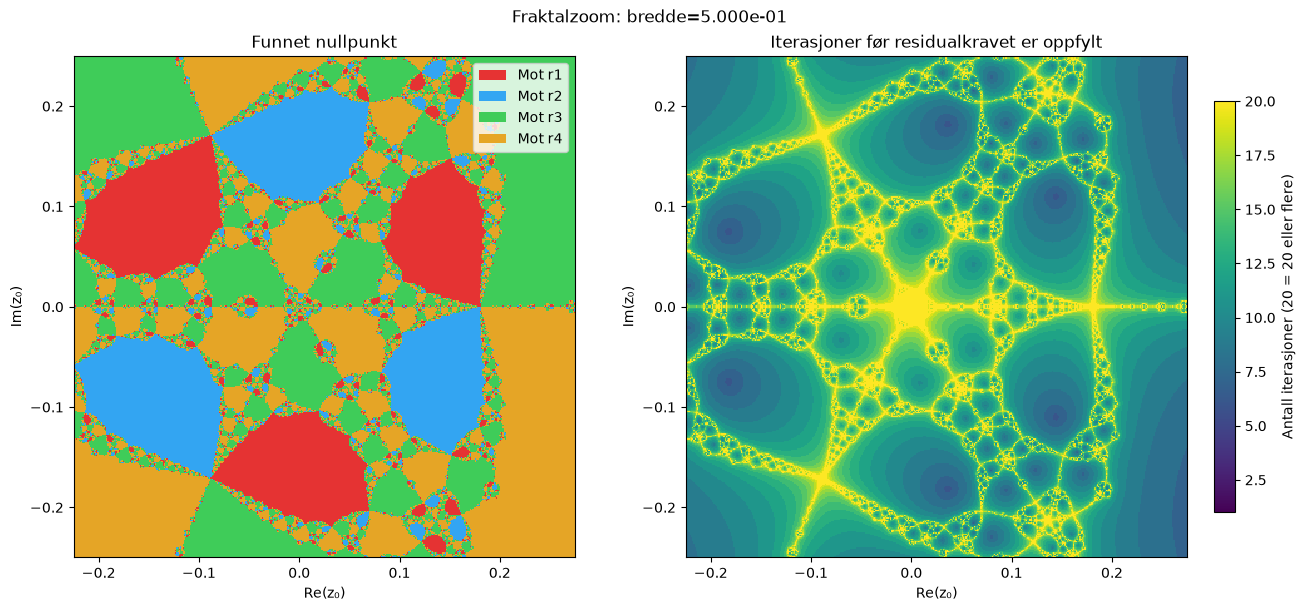

Bredde på vinduet:        5.0000e-01
Bredde per piksel:        1.2531e-03
Synlige basin:            4
Andel grensepiksler:      0.1823
Gj.snitt steg, grense:    18.40
Gj.snitt steg, indre:     11.33
Største steg, grense:     49


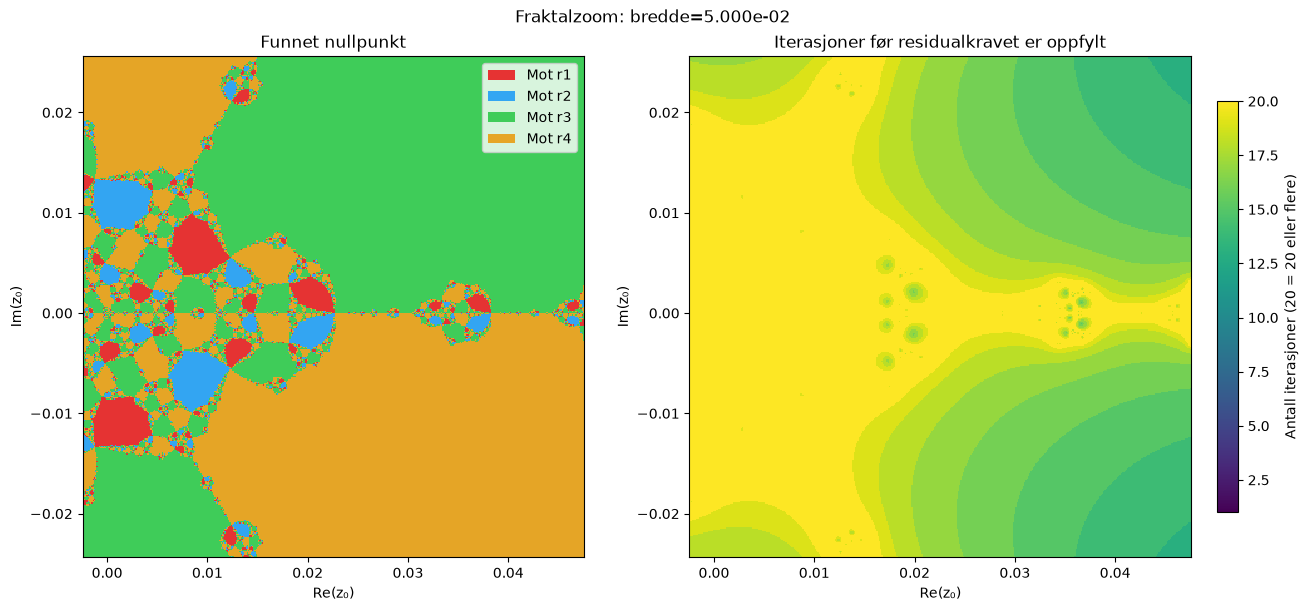

Bredde på vinduet:        5.0000e-02
Bredde per piksel:        1.2531e-04
Synlige basin:            4
Andel grensepiksler:      0.1051
Gj.snitt steg, grense:    29.32
Gj.snitt steg, indre:     18.46
Største steg, grense:     63


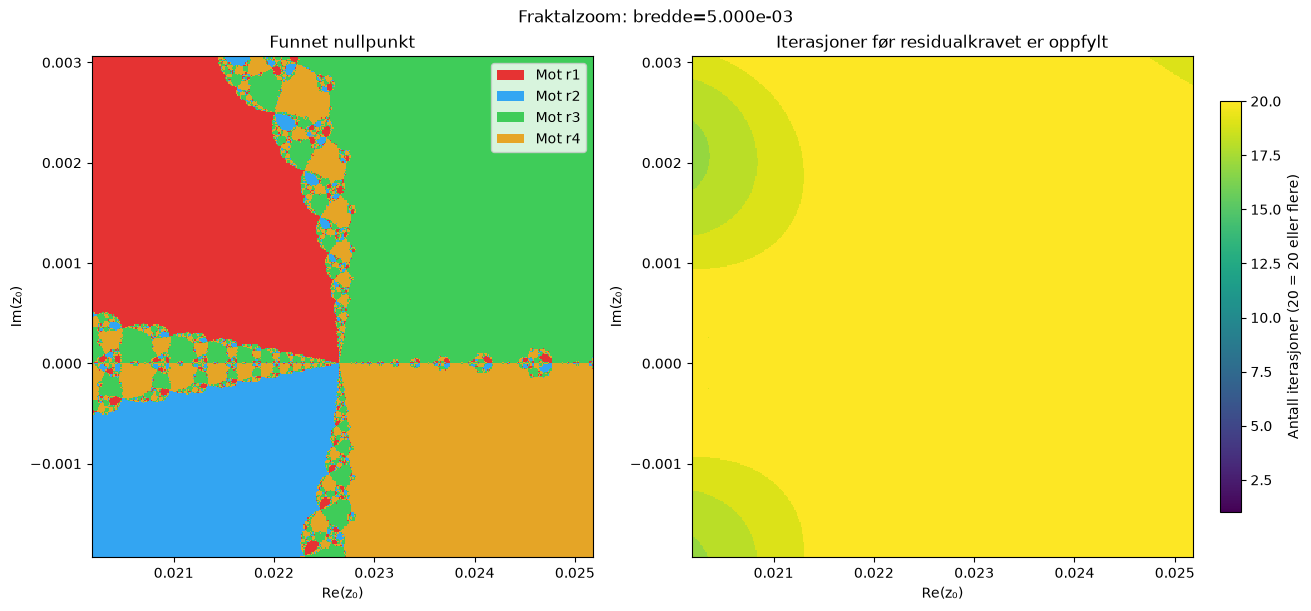

Bredde på vinduet:        5.0000e-03
Bredde per piksel:        1.2531e-05
Synlige basin:            4
Andel grensepiksler:      0.0736
Gj.snitt steg, grense:    30.65
Gj.snitt steg, indre:     22.03
Største steg, grense:     77


In [210]:
def square_bounds(center, width):
    """Lag et kvadratisk vindu rundt startverdien vi vil følge."""
    half = width/2
    return (center.real-half, center.real+half,
            center.imag-half, center.imag+half)

def plot_basins2(data, title="Newtons metode: tiltrekningsområder",
                 critical_points=None, iteration_cap=20):
    """Samme som plot_basins, men aksene begrenses til selve zoomområdet."""

    basin = data["basin"]
    iterations = data["iterations"]
    roots = data["roots"]
    xmin, xmax, ymin, ymax = data["bounds"]

    # Farger for tiltrekningsområdene
    basin_image = np.full(basin.shape + (3,), 0.25)
    basin_image[basin == -2] = 0.0

    legend_handles = []

    for k in range(len(roots)):
        mask = basin == k
        color = ROOT_COLORS[k % len(ROOT_COLORS)]
        basin_image[mask] = color
        legend_handles.append(
            Patch(facecolor=color, label=f"Mot r{k+1}")
        )

    plt.close("all")

    fig, (ax_basin, ax_iterations) = plt.subplots(
        1, 2,
        figsize=(13, 6),
        constrained_layout=True
    )

    # -------------------------
    # Venstre: tiltrekningsområder
    # -------------------------

    ax_basin.imshow(
        basin_image,
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        interpolation="nearest"
    )

    # Tegn bare nullpunkter som faktisk ligger inne i zoomvinduet
    for k, root in enumerate(roots):
        if xmin <= root.real <= xmax and ymin <= root.imag <= ymax:
            ax_basin.scatter(
                root.real, root.imag,
                c="white",
                edgecolors="black",
                s=70,
                marker="o"
            )

            ax_basin.annotate(
                f"r{k+1}",
                (root.real, root.imag),
                xytext=(7, 7),
                textcoords="offset points",
                color="black",
                weight="bold"
            )

    if critical_points is not None:
        for point in critical_points:
            if xmin <= point.real <= xmax and ymin <= point.imag <= ymax:
                ax_basin.scatter(
                    point.real,
                    point.imag,
                    c="black",
                    edgecolors="white",
                    s=70,
                    marker="X",
                    linewidths=1.5
                )

    ax_basin.set_title("Funnet nullpunkt")
    ax_basin.legend(handles=legend_handles, loc="best")

    # -------------------------
    # Høyre: iterasjoner
    # -------------------------

    converged = basin >= 0

    capped_iterations = np.ma.masked_where(
        ~converged,
        np.minimum(iterations, iteration_cap)
    )

    iteration_image = ax_iterations.imshow(
        capped_iterations,
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        interpolation="nearest",
        cmap="viridis",
        vmin=1,
        vmax=iteration_cap
    )

    # Tegn bare nullpunkter som ligger inne i zoomvinduet
    for root in roots:
        if xmin <= root.real <= xmax and ymin <= root.imag <= ymax:
            ax_iterations.scatter(
                root.real,
                root.imag,
                c="white",
                edgecolors="black",
                s=45,
                marker="o"
            )

    colorbar = fig.colorbar(
        iteration_image,
        ax=ax_iterations,
        shrink=0.82
    )

    colorbar.set_label(
        f"Antall iterasjoner ({iteration_cap} = {iteration_cap} eller flere)"
    )

    ax_iterations.set_title(
        "Iterasjoner før residualkravet er oppfylt"
    )

    # -------------------------
    # Viktig for zoomen
    # -------------------------

    for ax in (ax_basin, ax_iterations):
        ax.set_xlabel("Re(z₀)")
        ax.set_ylabel("Im(z₀)")
        ax.set_aspect("equal")

        # Vis KUN zoomområdet
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    fig.suptitle(title)

    plt.show()

def run_zoom(center, width, resolution=400, tol=1e-8, maxiter=100):
    """Beregn og vis ett nytt nivå i fraktalzoomen.

    Behold resolution, tol og maxiter når du sammenligner nivåene. Endre
    center og width for å følge grensen videre.
    """
    zoom_bounds = square_bounds(center, width)
    data = newton_grid(
        f, df, roots, zoom_bounds,
        nx=resolution, ny=resolution, tol=tol, maxiter=maxiter
    )
    plot_basins2(data, f"Fraktalzoom: bredde={width:.3e}")
    print_boundary_summary(data)
    return data

# Dette er nivå 1. Endre sentrum hvis grensen forsvinner ut av bildet.

zoom_center = boundary_point
zoom_width = min(bounds[1]-bounds[0], bounds[3]-bounds[2])
zoom_data = run_zoom(zoom_center, zoom_width)

zoom_center = suggest_boundary_point(zoom_data)
zoom_width = zoom_width / 10
zoom_data = run_zoom(zoom_center, zoom_width)

zoom_center = suggest_boundary_point(zoom_data)
zoom_width = zoom_width / 10
zoom_data = run_zoom(zoom_center, zoom_width)

zoom_center = suggest_boundary_point(zoom_data)
zoom_width = zoom_width / 10
zoom_data = run_zoom(zoom_center, zoom_width)

### Delproblem 4
_Funksjon `find_neighbor_points` ble laget ved hjelp av KI for å få to gode startverdier å bruke_

In [211]:
def find_neighbor_points(data):
    basin = data["basin"]
    xmin, xmax, ymin, ymax = data["bounds"]

    ny, nx = basin.shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    for row in range(ny):
        for col in range(nx - 1):
            if basin[row, col] >= 0 and basin[row, col + 1] >= 0:
                if basin[row, col] != basin[row, col + 1]:
                    z1 = x[col] + 1j*y[row]
                    z2 = x[col + 1] + 1j*y[row]
                    return z1, z2

z1, z2 = find_neighbor_points(zoom_data)

print("Nabopunkt 1:", z1)
print("Nabopunkt 2:", z2)
print("Avstand:", abs(z1 - z2))

z3 = 0.024 + 0.002j
print("Startverdi i ensfarget område:", z3)

res1 = newton_trace(f, df, roots, z1, tol=1e-8, maxiter=100)
res2 = newton_trace(f, df, roots, z2, tol=1e-8, maxiter=100)
res3 = newton_trace(f, df, roots, z3, tol=1e-8, maxiter=100)

print_trace(res1)
print_trace(res2)
print_trace(res3)

Nabopunkt 1: (0.02224937343358361-0.0019360902255643685j)
Nabopunkt 2: (0.022261904761904414-0.0019360902255643685j)
Avstand: 1.2531328320804225e-05
Startverdi i ensfarget område: (0.024+0.002j)
 n                 z_n             |f(z_n)|       skrittlengde
 0  0.022249373433584-0.0019360902255644j   1.022e+00           -
 1  -0.99995624389686-1.1725100502089e-05j   9.999e-01      1.022e+00
 2  -0.6666083216412-1.5635519894804e-05j   5.309e-01      3.333e-01
 3  2.204824050871-0.0012949640195394j   2.684e+01      2.871e+00
 4  1.5931337566062-0.0010532297849154j   9.035e+00      6.117e-01
 5  1.0670495541228-0.00098263772988549j   3.363e+00      5.261e-01
 6  0.49305839472786-0.0013151353566891j   1.552e+00      5.740e-01
 7  -0.55608042490738-0.0027206851139619j   5.395e-01      1.049e+00
 8  -2.2823264666091-0.055815914138036j   2.588e+01      1.727e+00
 9  -1.7270427054707-0.041614441630622j   8.179e+00      5.555e-01
10  -1.3104051364581-0.031654891402983j   2.640e+00      4.168e-0

#### Valgte nabostartverider med forskjellige basin-farge

For å undersøke følsomheten nær basin-grensen valgte jeg to nabostartverdier med forskjellig basin-farge:

$$
z_1 = 0.0222493734 - 0.0019360902i
$$

$$
z_2 = 0.0222619048 - 0.0019360902i
$$

Avstanden mellom startverdiene er

$$
|z_1-z_2| \approx 1.2531 \cdot 10^{-5}.
$$

#### En startverdi et stykke inne i et ensfarget området
Denne startverdien er funnet ved å lese av plottet
$$
z_3 = 0.024 + 0.002j
$$

### Sammenligning av de tre startverdiene

De to nabostartverdiene $z_1$ og $z_2$ har en avstand på

$$
1.2531 \cdot 10^{-5}
$$

De første iteratene er nesten like, men etter hvert begynner det å bli et skille. Til slutt så ser vi at de ender til ved forskjellige nullpunkter.

For $z_1$ var den største skrittlengden 3.718 ved n = 18. Punktet konvergerte etter 30 iterasjoner, med siste residual

$$
7.793 \cdot 10^{-16}.
$$

For $z_2$ var den største skrittlengden 4.860 ved n = 18. Punktet konvergerte etter 33 iterasjoner, med siste residual

$$
1.361 \cdot 10^{-16}.
$$

Det tredje punktet, som ligger inne i et ensfarget område, hadde den største skrittlengde 2.870 ved n = 3 og konvergerte etter 22 iterasjoner. Siste residual var

$$
3.742 \cdot 10^{-12}.
$$

`newton_trace` viser at to startverdier som ligger svært nær hverandre ved med ulik basin farge kan følge nesten samme iterasjonsforeløp i starten, men senere vil de skille lag og konvergere mot forskjellige nullpunkter. Punktet inne i det ensfargede området konvergerte raskere og hadde og forløpet var mer stabilt.

## Fraktal rapport
**Hva forventet du før du zoomet, og hva viste bildene?**
Jeg forvnetet at grensen etter hvert vil bli glattere dersom jeg zoomer langt nok inn. Jeg forvnetet også at indre piksler vil kreve færre iterasjoner enn grensepiksler, siden startverdier nær grensene ofte er mer følsomme og bruker lengre tid på å konvergere.

<br>

**Hvilke nye detaljer dukket opp på hvert nivå? Ble grensen noen gang en enkel, glatt linje?**
Det mer jeg zoomet inn, så oppdaget jeg flere små detaljere langs grensene. Grensene ble ikke glattere slik jeg forventet, men istedet så dukket det opp flere mindr eområder med forskjellige basin farger langs grensene.

Jeg ser også, ut ifra iterasjonsplottet, at punktene nær grenesene generelt krever flere iterasjoner for å oppfylle residualkravet. Punkter som ligger i ensfargede områder krever mindre.

<br>

**Så du nøyaktige kopier av tidligere mønstre, eller nye mønstre med lignende kompleksitet? Hvorfor kan begge deler omtales som fraktallignende?**

Jeg ser ikke nøyaktige mønstre, men det dukker opp nye mønstre som ligner veldig på tildigere mønstre.

Begge deler kan omtales som fraktallignende, da det kommer fram nye detaljer når vi zoomer inn.

<br>

**Hvor liten endring i $𝑧_0$ representerte én piksel på siste nivå?**

På siste nivå representere en piksel en endring på  omtrent

$$
1.2531 * 10^{-5}
$$

<br>

**Fortsatte nabopiksler å finne forskjellige nullpunkter på denne skalaen?**

Ja på dette nivået så fortsatte nabopiksler å finne forskjellige nullpunkter. $z_1$ og $z_2$ som har en avstand på $1.2531 * 10^{-5}$ endte opp med å finne to forskjellige nullpunkter.

<br>

**Hvordan skilte iterasjonstallene på grensen seg fra indre områder?**

Grensepikslene krevde flere iterasjoner enn piksler som ligger i indre område. På siste nivå var gjennomsnittlig iterasjoner for grensepiksler 30.65, mens for indre piskler lå den på 22.03.

<br>

**Hva viste de tre newton_trace-forsøkene om hvorfor fargene blir ulike?**


De tre forsøkene viser at de to nabostartverdiene følger nesten samme bane i starten. Rundt iterasjon 13 til 18 begynner banene å skille, og til slutt så konvergerer de to mot forskjellige nullpunkter. $z_3$ som lå i et ensfarget område konvergerte bedre og brukte færre iterasjoner. Dette viser at små forskjeller i startverdien nær en basin-grense kan gi helt forskjellige resultater, mens et punkt inne i et tiltrekningsområde oppfører seg mer stabilt

<br>

**Hvordan kan tol, maxiter og flyttallsregning påvirke de minste strukturene du ser?**

En strengere `tol` gjør at Newtons metode må komme nærmere et nullpunkt før punktet regnes som konvergert, og kan derfor kreve flere iterasjoner. Hvis `maxiter` er for lav, kan enkelte punkter stoppe før de rekker å oppfylle residualkravet.

<br>

**Hvorfor er flere vellykkede zoomnivåer god numerisk evidens for en fraktallignende grense, men ikke et bevis på detaljer på alle skalaer?**

Flere zoomnivåer viser at nye detaljer fortsetter å dukke opp selv når vi undersøker stadig mindre områder. Dette er god numerisk evidens for at grensen er fraktallignende.

Det er likevel ikke et matematisk bevis, fordi vi bare har undersøkt et begrenset antall zoomnivåer med et endelig antall piksler og begrenset flyttallspresisjon. Vi kan derfor ikke konkludere med at nye detaljer fortsetter på alle mulige skalaer.

## Konklusjon

Eksperimentene viser at startverdien har stor betydning for hvilket nullpunkt Newtons metode finner. Startverdier som ligger godt inne i et tiltrekningsområde konvergerer vanligvis raskt, mens punkter nær grensene ofte krever flere iterasjoner.

Metoden finner heller ikke alltid nullpunktet som ligger nærmest startverdien. I oppgave 4 var 17.63 % av de konvergerte startverdiene et annet nullpunkt enn det nærmeste. Dette skjedde ofte nær grensene mellom tiltrekningsområdene.

De kritiske punktene påvirker også iterasjonen fordi deriverten er null eller liten der. Nær slike punkter kan newton skrittene bli store og konvergensen treg. Perturbasjonsforsøkene og fraktalzoomen viste samtidig at små endringer i startverdien kan føre til forskjellige nullpunkter. Selv på det siste zoomnivået kunne to nabopiksler med en liten avstand konvergere mot forskjellige løsninger.

Resultatene avhenger også av `tol` og `maxiter`. En strengere toleranse krever vanligvis flere iterasjoner, mens en for lav `maxiter` kan føre til at punkter klassifiseres som ikke konvergert selv om de kunne ha konvergert med flere steg.

Resultatene gir numerisk evidens for denne oppførselen, men kan ikke bevise hva som skjer for alle mulige startverdier. Jeg mener det er forsvarlig å rapportere konvergens når residualen er mindre enn den valgte toleransen og stoppkriteriet er tydelig oppgitt.